In [38]:
import os
import sys
from pathlib import Path

library_path = os.path.abspath('../src')
if library_path not in sys.path:
    sys.path.append(library_path)
library_path = Path(library_path)
library_path

PosixPath('/mnt/DataVol/Beratungen/Yurttas/survival/src')

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats

In [40]:
# load data
DATA_PATH = "/mnt/DataVol/Beratungen/Yurttas/survival/data"
PLOTS_PATH = "/mnt/DataVol/Beratungen/Yurttas/survival/plots"

df = pd.read_csv(f"{DATA_PATH}/all_data.csv", sep="\t")
df.columns

Index(['Bday', 'OPDate', 'Sex', 'Zn HIPEC', 'Age', 'Tumor', 'Histo', 'T', 'N',
       'M', 'V', 'L', 'R', 'G', 'syn_met', 'Other M1', 'PreOP CTx',
       'PostOP CTx', 'Thermoablation', 'HIPEC Med', 'HIPEC Zeit', 'NaThio',
       'OP-Zeit', 'Kompli', 'Art Kompli', 'Re-OP durch Kompli',
       'Tod als Kompli', 'In-Hosp Mortalität', 'Tod 30d', 'Tod 90d',
       'Rechtskolon', 'Transkolon', 'Linkskolon', 'sPCI', 'pPCI', 'PCI Diff',
       'Präparate gesamt', 'Präparate positiv', 'Mutation', 'CC', 'Tod Datum',
       'OS', 'Rezidiv', 'Lok Rezidiv', 'Datum Rezidiv', 'Zeit bis Rezidiv',
       'SF Grund'],
      dtype='object')

In [41]:
cols_to_use = ["Sex", "Age", "Tumor", "Zn HIPEC", "PreOP CTx", "Thermoablation", "sPCI", "pPCI"]
df = df[cols_to_use].copy()

In [42]:
df.head()

,Sex,Age,Tumor,Zn HIPEC,PreOP CTx,Thermoablation,sPCI,pPCI
0,2,17,1,1,1,1,26,22
1,1,21,1,1,5,1,5,3
2,1,23,2,1,0,1,10,1
3,2,23,4,1,1,0,15,6
4,2,23,18,1,0,1,11,4


**Binary cols
1. `Sex`
2. `Zn HIPEC`
3. `Thermoablation`

** Continuous
1. `Age`

** Nominal
1. `PreOP CTx`
2. `Tumor`


In [43]:
df['PreOP CTx'].value_counts()

PreOP CTx
1    270
0    125
5     54
4      2
2      2
3      1
Name: count, dtype: int64

In [44]:
df['Tumor'].value_counts()

Tumor
1     122
5      89
4      74
6      52
7      28
3      27
2      20
8      11
9       8
16      5
18      5
13      4
17      3
11      3
10      1
19      1
15      1
Name: count, dtype: int64

In [45]:
df

,Sex,Age,Tumor,Zn HIPEC,PreOP CTx,Thermoablation,sPCI,pPCI
0,2,17,1,1,1,1,26,22
1,1,21,1,1,5,1,5,3
2,1,23,2,1,0,1,10,1
3,2,23,4,1,1,0,15,6
4,2,23,18,1,0,1,11,4
...,...,...,...,...,...,...,...,...
449,2,76,6,1,0,1,12,5
450,1,77,5,1,1,1,30,6
451,1,77,5,1,1,1,33,28
452,2,77,1,1,1,0,10,6


In [46]:
# data wrangling
df['Sex'] = df['Sex']-1
df['PreOP CTx'] = df['PreOP CTx'].apply(lambda x: 1 if x >= 1 else x)

keep_tumor = [1, 5, 4, 6, 7, 3, 2]  # remove 8 if you decide to drop it

# Filter rows
df = df[df["Tumor"].isin(keep_tumor)].copy()
df['Tumor'] = df['Tumor'].apply(lambda x: f"type_{x}")


In [47]:
df.shape

(412, 8)

In [48]:
# --- 1. Rename columns ---
df = df.rename(columns={
    "Zn HIPEC"  : "Zn_HIPEC",
    "PreOP CTx" : "PreOP_CTx",
})

In [49]:
df['Tumor'].value_counts()

Tumor
type_1    122
type_5     89
type_4     74
type_6     52
type_7     28
type_3     27
type_2     20
Name: count, dtype: int64

In [50]:
# --- 5. One-hot encode Tumor (most frequent as reference) ---
# Tumor "1" (n=122) is the natural reference category
df = pd.get_dummies(df, columns=["Tumor"], drop_first=False, dtype=int)
df = df.drop(columns=["Tumor_type_1"], inplace=False)  # explicitly set Tumor_1 as reference

# --- 6. Create outcome variables ---
df["raw_diff"] = df["sPCI"] - df["pPCI"]
df["abs_diff"] = np.abs(df["raw_diff"])


In [52]:
feature_cols = [
    'Sex', 'Age', 'Zn_HIPEC', 'PreOP_CTx', 'Thermoablation', 'Tumor_type_2', 'Tumor_type_3', 'Tumor_type_4', 'Tumor_type_5',
       'Tumor_type_6', 'Tumor_type_7'
]

X     = df[feature_cols]
y_raw = df["raw_diff"]
y_abs = df["abs_diff"]

print(f"Final feature matrix: {X.shape}")

Final feature matrix: (412, 11)


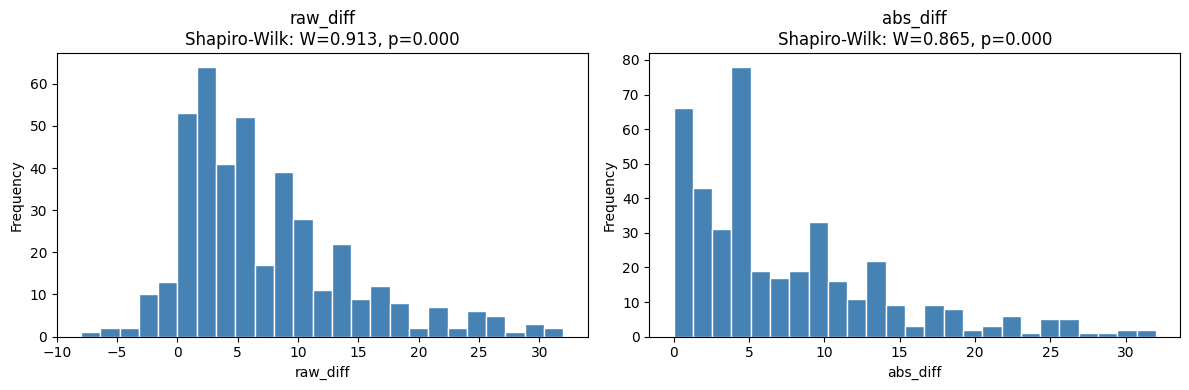

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, outcome, label in zip(axes, [y_raw, y_abs], ["raw_diff", "abs_diff"]):
    ax.hist(outcome, bins=25, color="steelblue", edgecolor="white")
    ax.set_title(f"Distribution of {label}")
    ax.set_xlabel(label)
    ax.set_ylabel("Frequency")
    stat, p = stats.shapiro(outcome)
    ax.set_title(f"{label}\nShapiro-Wilk: W={stat:.3f}, p={p:.3f}")

plt.tight_layout()
plt.show()

In [54]:
import statsmodels.api as sm

X = sm.add_constant(X)  # if not already included
model = sm.OLS(y_raw, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               raw_diff   R-squared:                       0.224
Model:                            OLS   Adj. R-squared:                  0.203
Method:                 Least Squares   F-statistic:                     10.52
Date:                 Di, 14 Apr 2026   Prob (F-statistic):           5.11e-17
Time:                        14:54:21   Log-Likelihood:                -1333.4
No. Observations:                 412   AIC:                             2691.
Df Residuals:                     400   BIC:                             2739.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              7.2307      2.439      2.

In [55]:
fitted = model.fittedvalues
residuals = model.resid

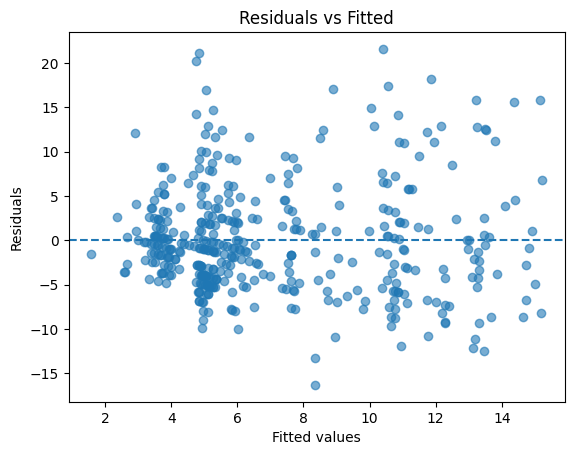

In [56]:
import matplotlib.pyplot as plt

plt.scatter(fitted, residuals, alpha=0.6)
plt.axhline(0, linestyle='--')
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()

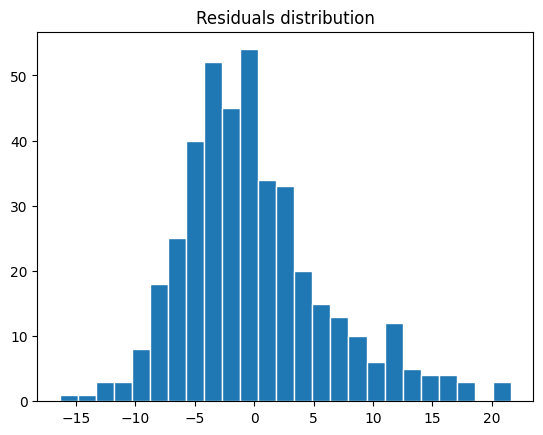

In [57]:
plt.hist(residuals, bins=25, edgecolor="white")
plt.title("Residuals distribution")
plt.show()

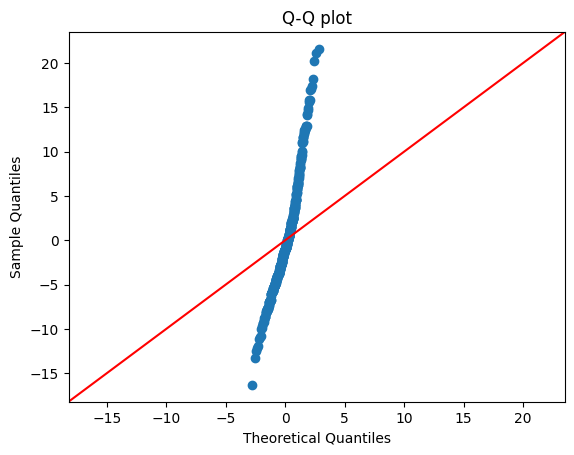

In [58]:
import statsmodels.api as sm

sm.qqplot(residuals, line='45')
plt.title("Q-Q plot")
plt.show()

In [59]:
from scipy import stats
stat, p = stats.shapiro(residuals)
print(f"W={stat:.3f}, p={p:.3f}")

W=0.956, p=0.000


In [60]:
from statsmodels.stats.diagnostic import het_breuschpagan

lm_stat, lm_pvalue, f_stat, f_pvalue = het_breuschpagan(residuals, X)

print(f"LM p-value: {lm_pvalue:.4f}")

LM p-value: 0.0000


In [63]:
from statsmodels.robust.robust_linear_model import RLM

model_rlm = RLM(y_raw, X).fit()
print(model_rlm.summary())

                    Robust linear Model Regression Results                    
Dep. Variable:               raw_diff   No. Observations:                  412
Model:                            RLM   Df Residuals:                      400
Method:                          IRLS   Df Model:                           11
Norm:                          HuberT                                         
Scale Est.:                       mad                                         
Cov Type:                          H1                                         
Date:                 Di, 14 Apr 2026                                         
Time:                        15:07:10                                         
No. Iterations:                    26                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const              7.6929      2.195      3.

In [67]:
type(model_rlm.weights < 0.001)

pandas.core.series.Series

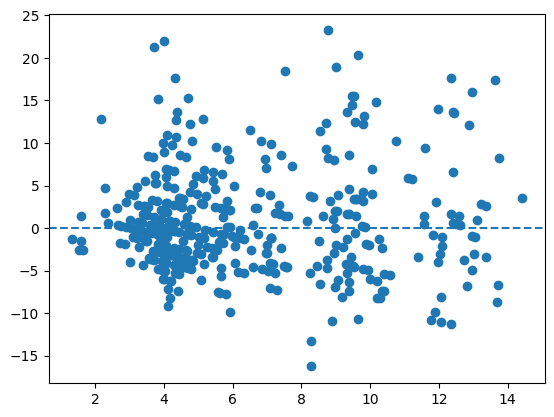

In [68]:
plt.scatter(model_rlm.fittedvalues, model_rlm.resid)
plt.axhline(0, linestyle='--')

In [71]:
y_raw

0       4
1       2
2       9
3       9
5      10
       ..
448    18
449     7
450    24
451     5
452     4
Name: raw_diff, Length: 412, dtype: int64

In [73]:
import statsmodels.formula.api as smf

data = df[feature_cols + ["raw_diff"]].copy()

formula = """
raw_diff ~ Sex + Age + Zn_HIPEC + PreOP_CTx + Thermoablation +
          Tumor_type_2 + Tumor_type_3 + Tumor_type_4 +
          Tumor_type_5 + Tumor_type_6 + Tumor_type_7
"""
model = smf.quantreg(formula, data)
res_50 = model.fit(q=0.5)
print(res_50.summary())

                         QuantReg Regression Results                          
Dep. Variable:               raw_diff   Pseudo R-squared:               0.1270
Model:                       QuantReg   Bandwidth:                       3.227
Method:                 Least Squares   Sparsity:                        12.66
Date:                 Di, 14 Apr 2026   No. Observations:                  412
Time:                        15:26:14   Df Residuals:                      400
                                        Df Model:                           11
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          6.7234      2.472      2.720      0.007       1.864      11.583
Sex               -0.4822      0.715     -0.675      0.500      -1.887       0.923
Age               -0.0426      0.027     -1.577      0.116      -0.096       0.010
Zn_HIPEC           2.9787      1

In [ ]:
quantiles = np.arange(0.1, 0.9, 0.1)

out = []

for q in quantiles:
    res = smf.quantreg(formula, data).fit(q=q)

    for var in res.params.index:
        out.append({
            "quantile": q,
            "variable": var,
            "coef": res.params[var],
            "pvalue": res.pvalues[var]
        })

results_df = pd.DataFrame(out)

In [76]:
results_df

,quantile,variable,coef,pvalue
0,0.1,Intercept,3.444464,7.953413e-02
1,0.1,Sex,0.222205,6.870842e-01
2,0.1,Age,-0.055556,2.968061e-03
3,0.1,Zn_HIPEC,0.388888,7.949256e-01
4,0.1,PreOP_CTx,0.111111,8.719131e-01
...,...,...,...,...
91,0.8,Tumor_type_3,1.999999,3.499519e-01
92,0.8,Tumor_type_4,3.000000,5.713708e-02
93,0.8,Tumor_type_5,11.999999,1.014733e-15
94,0.8,Tumor_type_6,-1.000001,5.870872e-01
